      date  precipitation  temp_max  temp_min  wind weather month
2012-01-01            0.0      12.8       5.0   4.7 drizzle   Jan
2012-01-02           10.9      10.6       2.8   4.5    rain   Jan
2012-01-03            0.8      11.7       7.2   2.3    rain   Jan


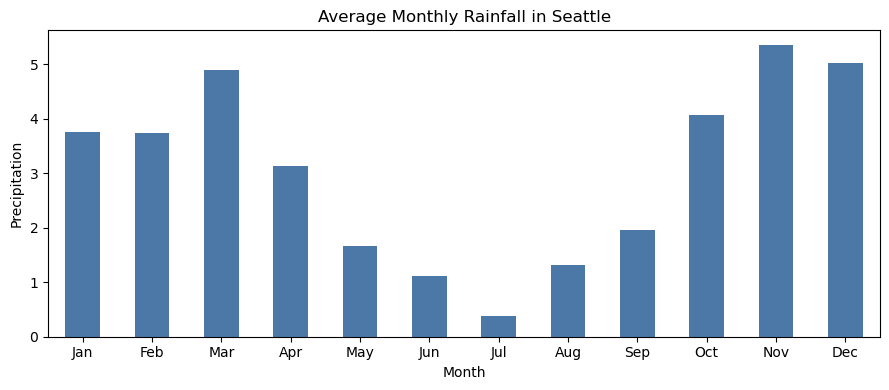

In [3]:
from pyodide.http import open_url
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/vega/vega-datasets/main/data/seattle-weather.csv"
df = pd.read_csv(open_url(url), parse_dates=["date"])

df["month"] = df["date"].dt.month_name().str.slice(stop=3)
monthly_rain = (
    df.groupby("month", sort=False)["precipitation"]
      .mean()
      .reindex(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
)

fig, ax = plt.subplots(figsize=(9, 4))
monthly_rain.plot(kind="bar", ax=ax, color="#4C78A8")
ax.set_title("Average Monthly Rainfall in Seattle")
ax.set_xlabel("Month")
ax.set_ylabel("Precipitation")
plt.xticks(rotation=0)
plt.tight_layout()

print(df.head(3).to_string(index=False))
plt.show()